# Clade C2 results

## Imports etc

In [285]:
# Load the correct grid parameters:
import importlib
!cp grid_params_clade_C2.py grid_params.py


In [286]:
# Import elfi_model.py
 
import elfi_model
importlib.reload(elfi_model)
from elfi_model import *


Loading BSI_functions.py
Grid parameters:
Clade: C2
Number of weeks to simulate: 728
Population size: 1000000
Year
2004     0.000390
2005     0.000395
2006     0.000421
2007     8.428780
2008     7.024155
2009     8.686990
2010     3.070367
2011     5.760377
2012    10.741828
2013    21.234113
2014    13.656576
2015    25.312731
2016    15.188393
2017    16.567411
Name: C2, dtype: float64
Model imported


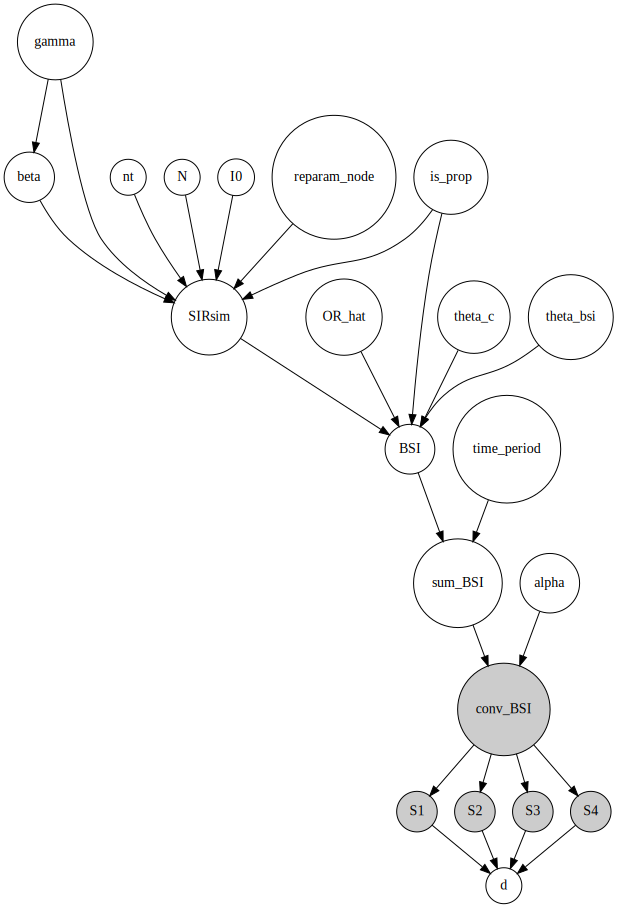

In [287]:
elfi.draw(m)

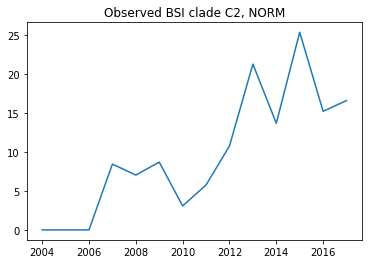

In [288]:
# Plot the observed data

plt.plot(bsi_obs_data)
plt.title(f"Observed BSI clade {clade}, {obs_data}")
plt.show()


In [289]:
get_OR_hat_pars(or_data, clade = "C2", dataset = "NORM")

(4.0923, 1.5136499999999997)

In [290]:
OR_hat.generate(10)

4.0923

## Visualizing the prior

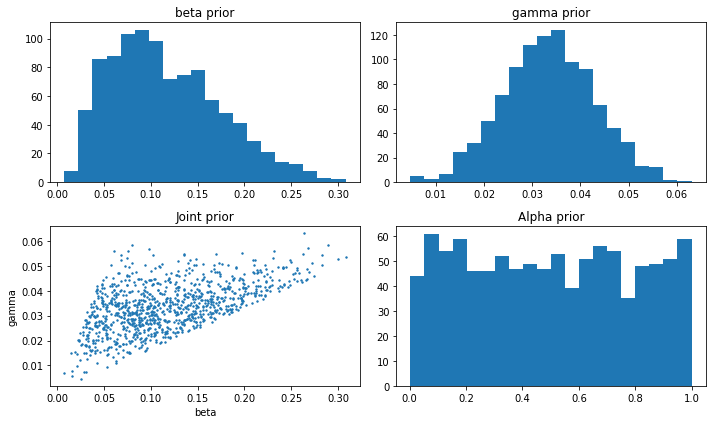

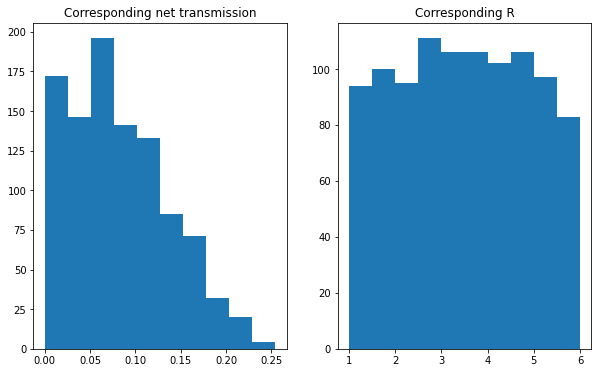

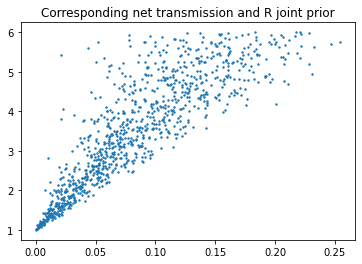

In [291]:
# Plot the priors
def plot_priors_elfi(par1 = "beta", par2 = "gamma"):
    # Plot priors from the elfi model. Currently supports only (beta, gamma) parametrisation.
    
    prior_sample =  m.generate(1000, outputs = [par1, par2])
    g = prior_sample[par2]
    b = prior_sample[par1]
    a_sample = alpha.generate(1000)


    fig, axs = plt.subplots(2, 2, figsize=(10, 6))
    axs[0, 0].hist(b, bins=20)
    axs[0, 0].set_title(f'{par1} prior')
    axs[0, 1].hist(g, bins=20)
    axs[0, 1].set_title(f'{par2} prior')

    axs[1, 0].scatter(b,g, s = 2)
    axs[1, 0].set_title('Joint prior')
    axs[1, 0].set_xlabel(f'{par1}')
    axs[1, 0].set_ylabel(f'{par2}')

    axs[1,1].hist(a_sample, bins=20)
    axs[1, 1].set_title('Alpha prior')
    plt.tight_layout()
    plt.show()

    if not reparam:
        fig, axs = plt.subplots(1, 2, figsize=(10, 6))
        nt_sample = b - g
        R_sample = b/g
        axs[0].hist(nt_sample)
        axs[0].set_title("Corresponding net transmission")

        axs[1].hist(R_sample)
        axs[1].set_title("Corresponding R")
        plt.show()


        plt.scatter(nt_sample, R_sample, s=2)
        plt.title("Corresponding net transmission and R joint prior")
        plt.show()

if not reparam:    
    plot_priors_elfi()
else:
    net_sample = net_transmission.generate(1000)
    R_sample = R.generate(1000)
    a_sample = alpha.generate(1000)

    #print(R_sample.shape)
    #print(net_sample.shape)
    
    fig, axs = plt.subplots(2, 2, figsize=(10, 6))
    axs[0, 0].hist(net_sample, bins=20)
    axs[0, 0].set_title('Net transmission prior')
    axs[0, 1].hist(R_sample, bins=20)
    axs[0, 1].set_title('R prior')
    
    axs[1, 0].scatter(net_sample, R_sample, s = 2)
    axs[1, 0].set_title('Joint prior')
    axs[1, 0].set_xlabel('Net transmission')
    axs[1, 0].set_ylabel('R')
    
    axs[1,1].hist(a_sample, bins=20)
    axs[1, 1].set_title('Alpha prior')
    plt.tight_layout()
    filename = "nt_R_beta_priors.pdf"
    plt.savefig(filename, format="pdf", bbox_inches="tight")
    plt.show()
    
    or_sample = OR_hat.generate(1000)
    plt.hist(or_sample)
    plt.title("OR prior")
    plt.show()
    

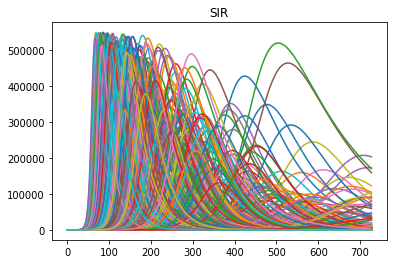

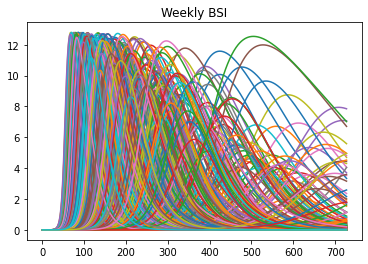

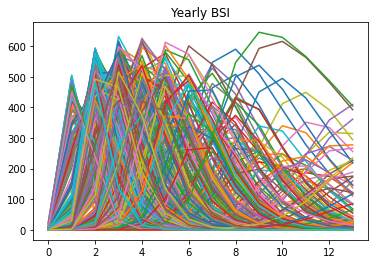

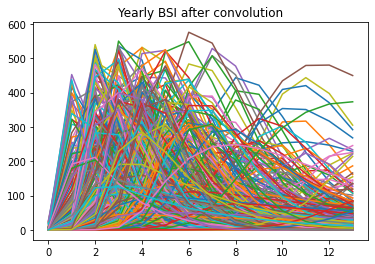

In [292]:
# Simulations from the prior:
sim_dict = m.generate(batch_size= 500, outputs = ["SIRsim", "BSI", "conv_BSI", "sum_BSI"])


plt.plot(sim_dict["SIRsim"][1].T)
plt.title("SIR")
plt.show()

plt.plot(sim_dict["BSI"].T)
plt.title("Weekly BSI")
plt.show()

plt.plot(sim_dict["sum_BSI"].T)
plt.title("Yearly BSI")
plt.show()

plt.plot(sim_dict["conv_BSI"].T)
plt.title("Yearly BSI after convolution")
plt.show()

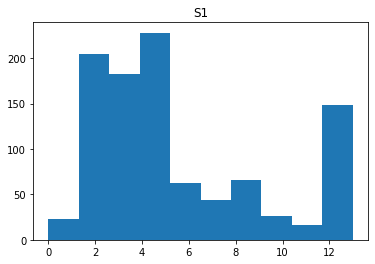

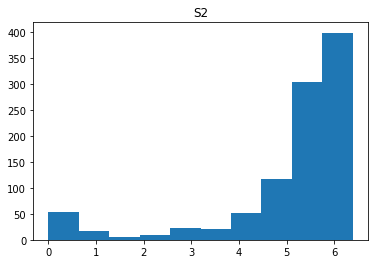

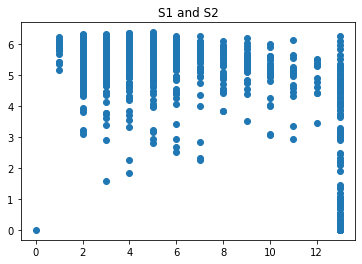

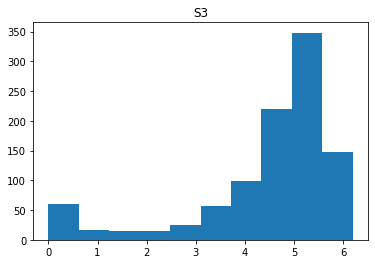

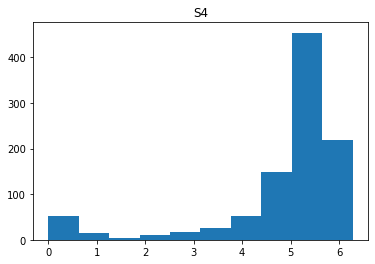

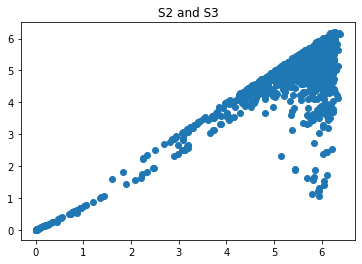

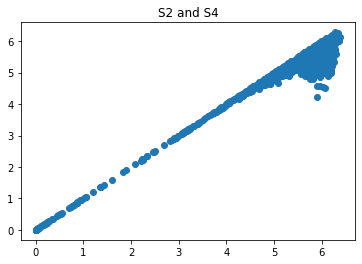

In [293]:
# Visualize summaries:
ssample = m.generate(1000, outputs = ["S1", "S2", "S3", "S4"])

plt.hist(ssample["S1"])
plt.title("S1")
plt.show()

plt.hist(ssample["S2"])
plt.title("S2")
plt.show()

plt.scatter(ssample["S1"], ssample["S2"])
plt.title("S1 and S2")
plt.show()

plt.hist(ssample["S3"])
plt.title("S3")
plt.show()
plt.hist(ssample["S4"])
plt.title("S4")
plt.show()

# Summaries S3 and S4 (next and previous BSI from BSI_max) have an almost identical distribution to that of BSI_max 

plt.scatter(ssample["S2"], ssample["S3"])
plt.title("S2 and S3")
plt.show()
plt.scatter(ssample["S2"], ssample["S4"]) # Especially this. BSI_max_next
plt.title("S2 and S4")
plt.show()


## Rejection sampling

In [294]:
rej = elfi.Rejection(d, batch_size=100)
%time result = rej.sample(10000, quantile = 0.01)

Progress [==================================================] 100.0% Complete
CPU times: user 4min 52s, sys: 6.21 s, total: 4min 59s
Wall time: 4min 52s


In [295]:
#rej = elfi.SMC(d, batch_size=100)
#%time result = rej.sample(1000, thresholds = [1e12, 10000, 1000]) # Problem: lack of logpdf for custom beta prior :)

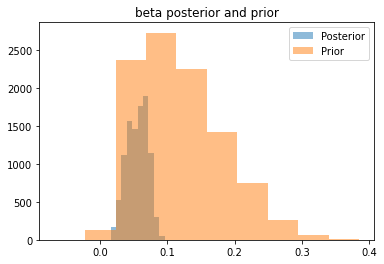

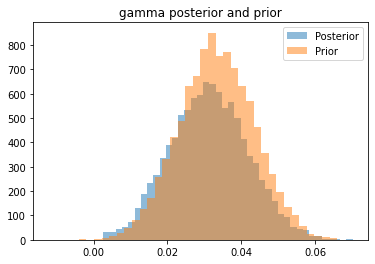

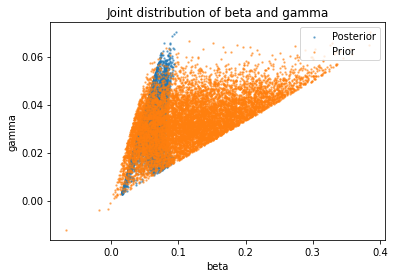

OR hat was not included as an estimated parameter.
Theta_bsi was not included as an estimated parameter.


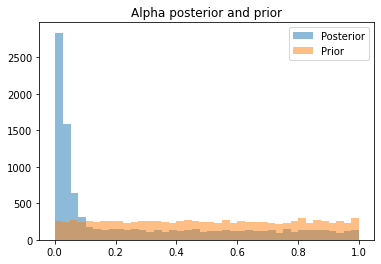

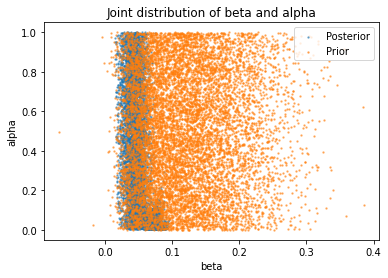

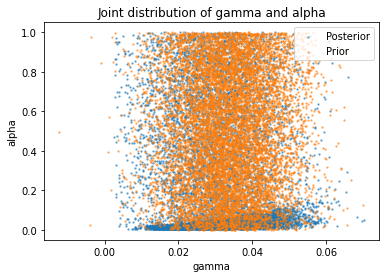

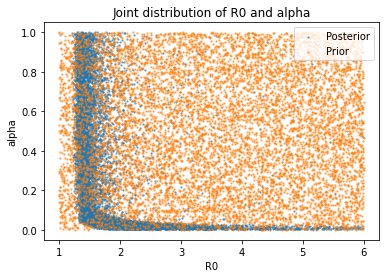

In [296]:
# Prior and posterior in the same figure
#pars_to_sample = ['OR_hat']
#pars_to_sample = ['theta_bsi']
pars_to_sample = ['alpha']
#pars_to_sample = []

if reparam:
    par1 = "net_transmission"
    par2 = "R"
    
else:
    par1 = "beta"
    par2 = "gamma"
    

pars_to_sample.append(par1)
pars_to_sample.append(par2)

if not reparam:
    
    sample = m.generate(10000, pars_to_sample)
    
   

    # Beta or net transmission
    plt.hist(result.samples[par1], alpha = 0.5, label = "Posterior")
    plt.hist(sample[par1], alpha = 0.5, label = "Prior")
    plt.title(f"{par1} posterior and prior")
    plt.legend(loc = "upper right")
    plt.show()

    # Gamma or R
    plt.hist(result.samples[par2], alpha = 0.5, label = "Posterior", bins = 40) # Differences are explained by stochasticity. Try running multiple times.
    plt.hist(sample[par2], alpha = 0.5, label = "Prior", bins = 40)
    plt.title(f"{par2} posterior and prior")
    plt.legend(loc = "upper right")
    plt.show()
    
    # Joint prior: beta, gamma
    plt.scatter(result.samples[par1], result.samples[par2], alpha = 0.5, s = 2, label = "Posterior")
    plt.scatter(sample[par1], sample[par2], alpha = 0.5, s= 2, label = "Prior")
    plt.title(f"Joint distribution of {par1} and {par2}")
    plt.xlabel(f"{par1}")
    plt.ylabel(f"{par2}")
    plt.legend(loc = "upper right")
    plt.show()

    try:
        # OR_hat

        plt.hist(result.samples['OR_hat'], alpha = 0.5, label = "Posterior", bins = 40) # Differences are explained by stochasticity. Try running multiple times.
        plt.hist(sample['OR_hat'], alpha = 0.5, label = "Prior", bins = 40) # negative OR_hat values are rejected by the simulator -> could explain this.
        plt.title("OR_hat posterior and prior")
        plt.legend(loc = "upper right")
        plt.show()
    except:
        print("OR hat was not included as an estimated parameter.")

    try:
        # theta_bsi
        plt.hist(result.samples['theta_bsi'], alpha = 0.5, label = "Posterior", bins = 40) # Differences are explained by stochasticity. Try running multiple times.
        plt.hist(sample['theta_bsi'], alpha = 0.5, label = "Prior", bins = 40) # negative OR_hat values are rejected by the simulator -> could explain this.
        plt.title("Theta_bsi posterior and prior")
        plt.legend(loc = "upper right")
        plt.show()
    except:
        print("Theta_bsi was not included as an estimated parameter.")
        
    try:
        # OR_hat

        plt.hist(result.samples['alpha'], alpha = 0.5, label = "Posterior", bins = 40) # Differences are explained by stochasticity. Try running multiple times.
        plt.hist(sample['alpha'], alpha = 0.5, label = "Prior", bins = 40) # negative OR_hat values are rejected by the simulator -> could explain this.
        plt.title("Alpha posterior and prior")
        plt.legend(loc = "upper right")
        plt.show()
    except:
        print("Alpha was not included as an estimated parameter.")
    
    
    try:
        # Joint prior: beta, OR

        plt.scatter(result.samples[par1], result.samples['OR_hat'], alpha = 0.5, s = 2, label = "Posterior")
        plt.scatter(sample[par1], sample['OR_hat'], alpha = 0.5, s= 2, label = "Prior")
        plt.title(f"Joint distribution of {par1} and OR_hat")
        plt.xlabel(f"{par1}")
        plt.ylabel("OR")
        plt.legend(loc = "upper right")
        plt.show()


        # Joint prior: gamma, OR

        plt.scatter(result.samples[par2], result.samples['OR_hat'], alpha = 0.5, s = 2, label = "Posterior")
        plt.scatter(sample[par2], sample['OR_hat'], alpha = 0.5, s= 2, label = "Prior")
        plt.title(f"Joint distribution of {par2} and OR_hat")
        plt.xlabel(f"{par2}")
        plt.ylabel("OR")
        plt.legend(loc = "upper right")
        plt.show()
    except:
        pass
    
    try:
        # Joint prior: beta, alpha

        plt.scatter(result.samples[par1], result.samples['alpha'], alpha = 0.5, s = 2, label = "Posterior")
        plt.scatter(sample[par1], sample['alpha'], alpha = 0.5, s= 2, label = "Prior")
        plt.title(f"Joint distribution of {par1} and alpha")
        plt.xlabel(f"{par1}")
        plt.ylabel("alpha")
        plt.legend(loc = "upper right")
        plt.show()


        # Joint prior: gamma, alpha

        plt.scatter(result.samples[par2], result.samples['alpha'], alpha = 0.5, s = 2, label = "Posterior")
        plt.scatter(sample[par2], sample['alpha'], alpha = 0.5, s= 2, label = "Prior")
        plt.title(f"Joint distribution of {par2} and alpha")
        plt.xlabel(f"{par2}")
        plt.ylabel("alpha")
        plt.legend(loc = "upper right")
        plt.show()
    except:
        
        pass
    
    try:
        # Joint prior: par1, theta_bsi

        plt.scatter(result.samples[par1], result.samples['theta_bsi'], alpha = 0.5, s = 2, label = "Posterior")
        plt.scatter(sample[par1], sample['theta_bsi'], alpha = 0.5, s= 2, label = "Prior")
        plt.title(f"Joint distribution of {par1} and theta_bsi")
        plt.xlabel(f"{par1}")
        plt.ylabel("theta_bsi")
        plt.legend(loc = "upper right")
        plt.show()


        # Joint prior: par2, theta_bsi

        plt.scatter(result.samples[par2], result.samples['theta_bsi'], alpha = 0.5, s = 2, label = "Posterior")
        plt.scatter(sample[par2], sample['theta_bsi'], alpha = 0.5, s= 2, label = "Prior")
        plt.title(f"Joint distribution of {par2} and theta_bsi")
        plt.xlabel(f"{par2}")
        plt.ylabel("theta_bsi")
        plt.legend(loc = "upper right")
        plt.show()
    
    except:
        pass
        
 

    plt.scatter(result.samples[par1]/result.samples[par2], result.samples['alpha'], alpha = 0.5, s = 2, label = "Posterior")
    plt.scatter(sample[par1]/sample[par2], sample['alpha'], alpha = 0.5, s = 2, label = "Prior")
    plt.title(f"Joint distribution of R0 and alpha")
    plt.xlabel("R0")
    plt.ylabel("alpha")
    plt.legend(loc = "upper right")
    plt.show()


array([[<AxesSubplot: ylabel='alpha'>, <AxesSubplot: >, <AxesSubplot: >],
       [<AxesSubplot: ylabel='beta'>, <AxesSubplot: >, <AxesSubplot: >],
       [<AxesSubplot: xlabel='alpha', ylabel='gamma'>,
        <AxesSubplot: xlabel='beta'>, <AxesSubplot: xlabel='gamma'>]],
      dtype=object)

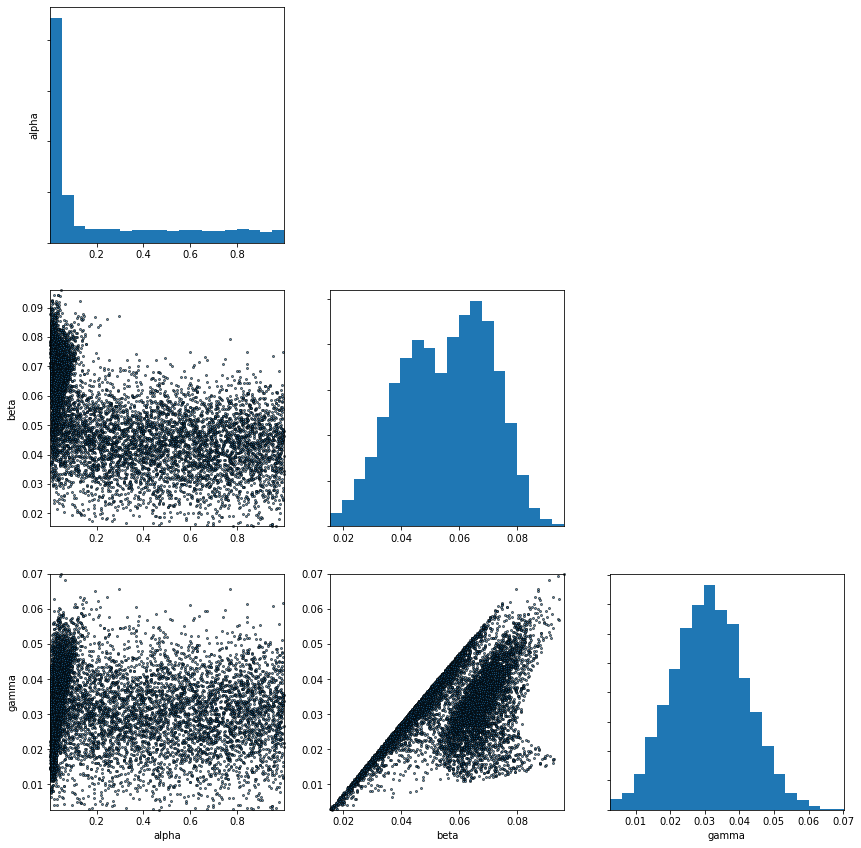

In [297]:
result.plot_pairs()

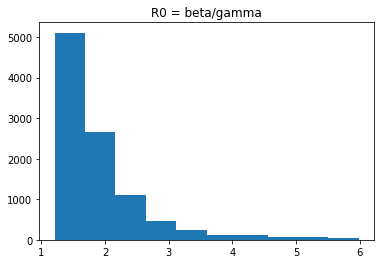

Mean of R: 1.9109646049388849
Median of R: 1.6722487095511869


In [298]:
# Plotting R0

if not reparam:
    R = result.samples['beta']/result.samples['gamma']
else:
    R = result.samples['R']

plt.hist(R)
plt.title("R0 = beta/gamma")
plt.show()

print(f"Mean of R: {R.mean()}")
print(f"Median of R: {np.median(R)}")

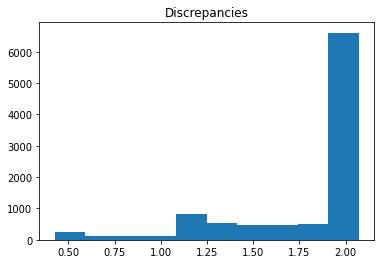

In [299]:
plt.hist(result.discrepancies)
plt.title("Discrepancies")
plt.show()

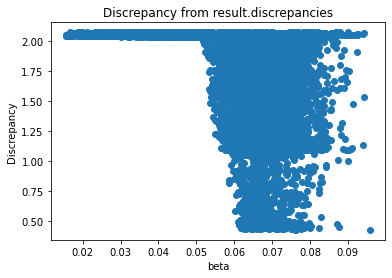

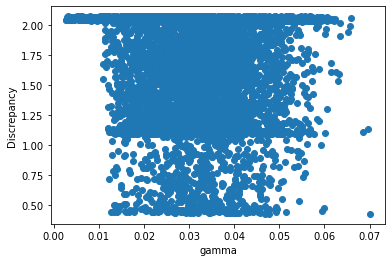

'\nplt.scatter(result.samples[\'OR_hat\'], result.discrepancies)\nplt.xlabel("OR")\nplt.ylabel("Discrepancy")\nplt.show()\n\n'

In [300]:
plt.scatter(result.samples[par1], result.discrepancies)
plt.title("Discrepancy from result.discrepancies")
plt.xlabel(f"{par1}")
plt.ylabel("Discrepancy")
plt.show()

plt.scatter(result.samples[par2], result.discrepancies)
plt.xlabel(f"{par2}")
plt.ylabel("Discrepancy")
plt.show()

"""
plt.scatter(result.samples['OR_hat'], result.discrepancies)
plt.xlabel("OR")
plt.ylabel("Discrepancy")
plt.show()

"""

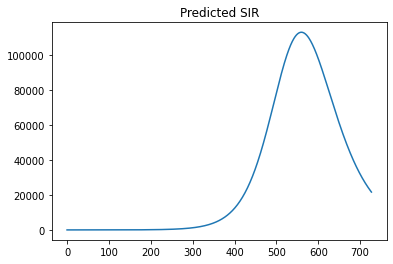

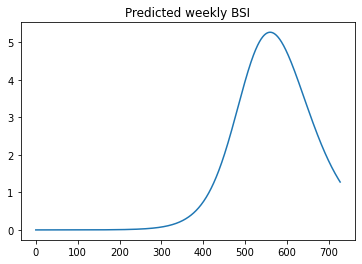

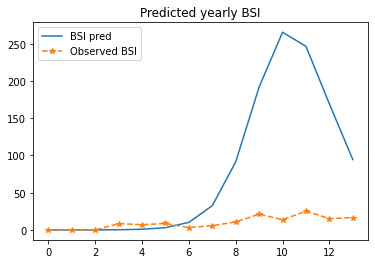

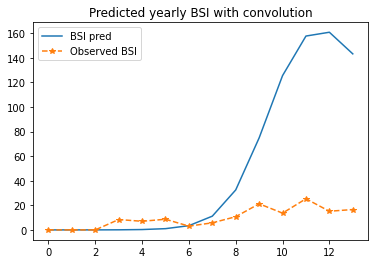

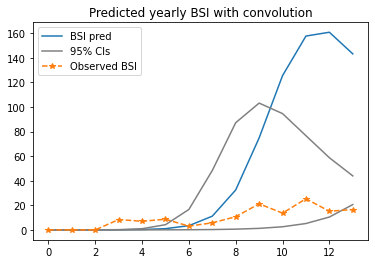

In [301]:
# Using elfi.generate

n_rep = 10 # Note: if OR hat is not fixed, we get different curves for each batch (they differ in height)

if reparam:
    par1 = "net_transmission"
    par2 = "R"
else:
    par1 = "beta"
    par2 = "gamma"

SIR_pred = SIRsim.generate(n_rep , with_values = {par1:np.mean(result.samples[par1]), par2:np.mean(result.samples[par2])}) # 10 samples, because then we can see 
    #if there's a mistake (more than 1 curve)
#"theta_bsi":np.mean(result.samples["theta_bsi"]), 
try:
    BSI_pred = BSI.generate(n_rep, with_values = {"SIRsim":SIR_pred, "OR_hat":np.mean(result.samples["OR_hat"])})
except: # OR was a constant
    BSI_pred = BSI.generate(n_rep, with_values = {"SIRsim":SIR_pred, "OR_hat":OR_hat.generate(1)})
BSI_yearly_pred = sum_BSI.generate(n_rep , with_values = {"BSI":BSI_pred})

try:
    BSI_conv_pred = conv_BSI.generate(n_rep , with_values = {"sum_BSI":BSI_yearly_pred, "alpha": np.mean(result.samples["alpha"])})
except:
    BSI_conv_pred = conv_BSI.generate(n_rep , with_values = {"sum_BSI":BSI_yearly_pred})
    
plt.plot(SIR_pred[1].T)
plt.title("Predicted SIR")
plt.show()

plt.plot(BSI_pred.T)
plt.title("Predicted weekly BSI")
plt.show()


plt.plot(BSI_yearly_pred.T, label = "BSI pred")
plt.plot(np.array(bsi_obs_data), label = "Observed BSI", marker = '*', linestyle = '--')
plt.title("Predicted yearly BSI")
plt.legend()
plt.show()


plt.plot(BSI_conv_pred.T, label = "BSI pred")
plt.plot(np.array(bsi_obs_data), label = "Observed BSI", marker = '*', linestyle = '--')
plt.title("Predicted yearly BSI with convolution")
plt.legend()
plt.show()

# 95% credible intervals: nope - ei toimi.

ci = 95
par1_ci = np.percentile(result.samples[par1], [(100-ci)/2, 100 - (100-ci)/2])
par2_ci = np.percentile(result.samples[par2], [(100-ci)/2, 100 - (100-ci)/2])


# Lower:
SIR_pred_l = SIRsim.generate(n_rep , with_values = {par1:par1_ci[0], par2:par2_ci[0]})
try:
    BSI_pred_l = BSI.generate(n_rep , with_values = {"SIRsim":SIR_pred_l, "OR_hat":np.mean(result.samples["OR_hat"])})
except:
    BSI_pred_l = BSI.generate(n_rep , with_values = {"SIRsim":SIR_pred_l, "OR_hat":OR_hat.generate(1)})
BSI_yearly_pred_l = sum_BSI.generate(n_rep , with_values = {"BSI":BSI_pred_l})


try:
    BSI_conv_pred_l = conv_BSI.generate(n_rep, with_values = {"sum_BSI":BSI_yearly_pred_l, "alpha": np.mean(result.samples["alpha"])})
except:
    BSI_conv_pred_l = conv_BSI.generate(n_rep, with_values = {"sum_BSI":BSI_yearly_pred_l})

# Upper:
SIR_pred_u = SIRsim.generate(n_rep, with_values = {par1:par1_ci[1], par2:par2_ci[1]})
try:
    BSI_pred_u = BSI.generate(n_rep , with_values = {"SIRsim":SIR_pred_u, "OR_hat":np.mean(result.samples["OR_hat"])})
except:
    BSI_pred_u = BSI.generate(n_rep , with_values = {"SIRsim":SIR_pred_u, "OR_hat":OR_hat.generate(1)})
BSI_yearly_pred_u = sum_BSI.generate(n_rep , with_values = {"BSI":BSI_pred_u})

try:
    BSI_conv_pred_u = conv_BSI.generate(n_rep , with_values = {"sum_BSI":BSI_yearly_pred_u, "alpha": np.mean(result.samples["alpha"])})
except:
    BSI_conv_pred_u = conv_BSI.generate(n_rep , with_values = {"sum_BSI":BSI_yearly_pred_u})


plt.plot(BSI_conv_pred.T, label = "BSI pred")
plt.plot(BSI_conv_pred_u.T, label = f"{ci}% CIs", color = "grey")
plt.plot(BSI_conv_pred_l.T, color = "grey")
plt.plot(np.array(bsi_obs_data), label = "Observed BSI", marker = '*', linestyle = '--')
plt.title("Predicted yearly BSI with convolution")
plt.legend()
plt.show()
    



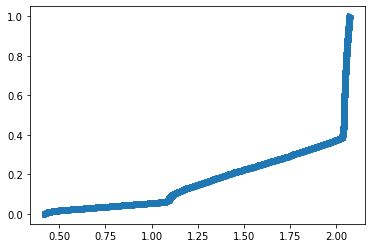

In [302]:
def ecdf(x):
    xs = np.sort(x)
    ys = np.arange(1, len(xs)+1)/float(len(xs))
    return xs, ys

xs, ys = ecdf(result.discrepancies)
plt.plot(xs, ys, label="handwritten", marker=">", markerfacecolor='none')

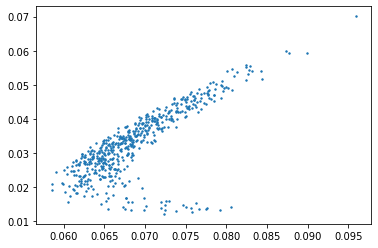

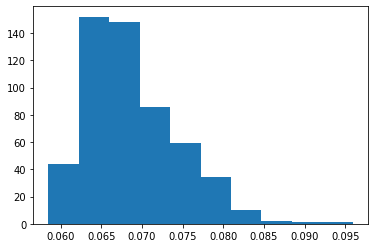

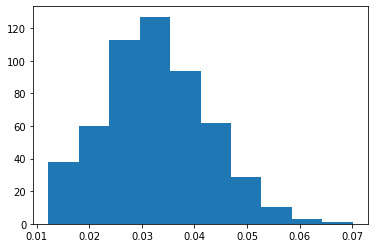

In [303]:
eps = 1
p1 = result.samples[par1][np.where(result.discrepancies < eps)]
p2 = result.samples[par2][np.where(result.discrepancies < eps)]

plt.scatter(p1, p2, s = 2)
plt.show()

plt.hist(p1)
plt.show()

plt.hist(p2)
plt.show()

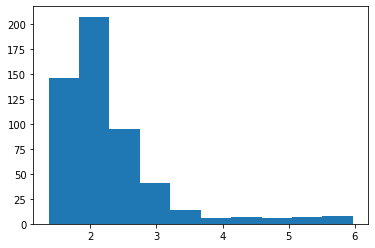

R0 mean: 2.2996285495902713
R0 median: 2.061638941237979


In [304]:
if not reparam:
    plt.hist(p1/p2)
    plt.show()
    print(f"R0 mean: {np.mean(p1/p2)}")
    print(f"R0 median: {np.median(p1/p2)}")
else:
    plt.hist(p2)
    plt.show()
    print(f"R mean: {np.mean(p2)}")
    print(f"R median: {np.median(p2)}")
    
    